# Data Bias: Fairness Gerrymandering

In this exercise you will slip into the role of data scientists that are requested as data experts for a judicial dispute.
The scenario in dispute is as follows:

A woman of color applied for a job at the company *MajorEngine*, but got rejected.
She suspects that she got turned down for racist and sexist reasons, *i.e.* because she is a woman of color.
*MajorEngine* refutes this claim and provides employment records in court in order to disprove the claims.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load the data from the file 'hiring_records_MajorEngine.csv' and inspect the first rows with the pandas function 'head'
# TODO: Your code goes here

### Task 1

Slip into the role of a data scientist hired by *MajorEngine* in order to show that based on the employment records

__(a)__ the company has no racist hiring policy, and

__(b)__ has no strongly sexist hiring policy. Note that according to the [2020 U.S. census](https://en.wikipedia.org/wiki/Race_and_ethnicity_in_the_United_States), the perfect, expected percentage of white employees would be 61.6%.

Use bar charts to convey your findings to a lay person and write a comment that explains your figure in favor of *MajorEngine*.

*Hint: While exploring the dataset, look at the ratio of white employees vs. non-white employees, and the ratio of male employees vs. non-male employees. It can also be useful to create a plot of the ideal distribution as comparison.*

In [3]:
# Part (a): show that MajorEngine has no strongly racist hiring policy

df = pd.read_csv('hiring_records_MajorEngine.csv')
df_race = df.value_counts("race")
percentage_white = 100 /(df.shape[0] / df_race['white'])
print(percentage_white)

#The result shows that 70% of the employees are white which isn't too far away from the perfect percentage of 61.6%

70.0


In [4]:
# Part (b): Show that MajorEngine has no sexist hiring policy

df_race = df.value_counts("gender")
percentage_female = 100 /(df.shape[0] / df_race['female'])
print(percentage_female)


#With a result of 49.7% no sexist hiring policy can be detected

49.7


<Figure size 640x480 with 0 Axes>

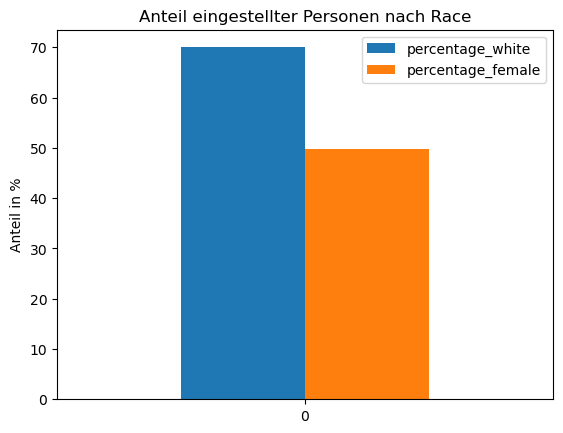

In [12]:
data = {'percentage_white': [percentage_white],
        'percentage_female': [percentage_female]}
df1 = pd.DataFrame(data)

plt.figure()
df1.plot(kind="bar")
plt.ylabel("Anteil in %")
plt.title("Anteil eingestellter Personen nach Race")
plt.xticks(rotation=0)
plt.show()

### Task 2

Slip into the role of a data scientist that works pro bono in order to demonstrate that *MajorEngine* has exhibited a bias in the past and thus is likely to have treated the woman of color unfairly.

Use a confusion matrix to convey your findings to a lay person.

*Hint: While superficially, the argumentation form task 1 may seem sound, you have the sneaking suspicion that you should look at the two attributes 'race' and 'gender' in combination instead of separately.*

*Second hint: You may create a makeshift confusion matrix by creating another pandas dataframe of the four intersectional values and renaming columns and index.*

In [5]:
df_gender_race = df.loc[df['gender'] == 'female']
df_race_female = df_gender_race.value_counts("race")
df_white_female_percentage = 100 / (df_gender_race.shape[0] / df_race_female['white'])
df_white_female_number = df_race_female['white']
df_women_of_colour = df_gender_race.shape[0] - df_white_female_number
print(df_white_female_percentage)

data = {'white women':[df_gender_race.shape[0] * 0.61, df_white_female_number], 'women of colour': [df_gender_race.shape[0] * 0.39, df_women_of_colour]}
con_matrix = pd.DataFrame(data)

con_matrix.rename(index={0: 'Prediction', 1: 'Actual'}, inplace=True)

print(con_matrix)

#The results show that only white women were hired

100.0
            white women  women of colour
Prediction       303.17           193.83
Actual           497.00             0.00


Side note: The court case and its arguments are based on a true story. The provided data is obviously made up in order to paint a clearer picture for pedagogic reasons.